In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
# Celda 1

# 1. Carga del conjunto de datos usando la ruta absoluta
ruta_archivo = '/workspace/spam.csv'
df = pd.read_csv(ruta_archivo, encoding='latin-1')

# Mostramos las primeras filas para verificar
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
# Celda 2

# 2. Limpieza de datos: Eliminar columnas innecesarias
# Nos quedamos solo con las dos primeras columnas
df = df.iloc[:, [0, 1]]

# Renombrar las columnas para mayor claridad
df.columns = ['label', 'message']

# Mostramos cómo ha quedado el dataset limpio
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
# Celda 3

# Descargar recursos necesarios de NLTK (solo hace falta ejecutarlo una vez)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english')) # Usamos inglés porque los SMS están en ese idioma

def clean_text(text):
    # 1. Convertir a minúsculas
    text = text.lower()
    # 2. Eliminar caracteres especiales y números (dejamos solo letras)
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. Tokenización (dividir en palabras)
    words = text.split()
    # 4 & 5. Eliminar stopwords y aplicar lematización
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    # Volver a unir las palabras en una sola cadena de texto
    return ' '.join(words)

# Aplicar la función de limpieza a la columna de mensajes
df['clean_message'] = df['message'].apply(clean_text)

# Mostrar el antes y el después
df[['message', 'clean_message']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\marco\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\marco\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\marco\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


In [5]:
# Celda 4

# 1. Instanciar TF-IDF limitando a 5000 características (las palabras más importantes)
tfidf = TfidfVectorizer(max_features=5000)

# Transformar los textos en vectores numéricos (X)
X = tfidf.fit_transform(df['clean_message']).toarray()

# Convertir las etiquetas de texto ('spam', 'ham') a valores numéricos (y)
# spam = 1, ham = 0
y = df['label'].map({'spam': 1, 'ham': 0}).values

print("Forma de la matriz X:", X.shape)
print("Forma del vector y:", y.shape)

Forma de la matriz X: (5572, 5000)
Forma del vector y: (5572,)


In [6]:
# Celda 5

# 2. Dividir en entrenamiento (80%) y validación (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Datos de entrenamiento:", X_train.shape[0])
print("Datos de validación:", X_test.shape[0])

Datos de entrenamiento: 4457
Datos de validación: 1115


In [7]:
# Celda 6

# 1. Selección del modelo
modelo = MultinomialNB()

# 2. Entrenamiento del modelo
modelo.fit(X_train, y_train)

print("¡Modelo entrenado exitosamente!")

¡Modelo entrenado exitosamente!


Precisión (Accuracy): 0.9704
Recall (Sensibilidad para Spam): 0.7867
F1-Score: 0.8773

Reporte detallado de Clasificación:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       965
           1       0.99      0.79      0.88       150

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



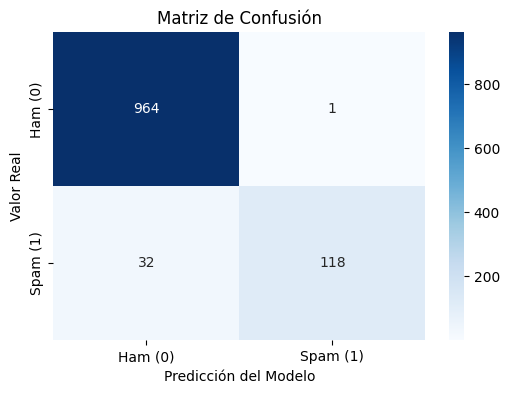

In [8]:
# Celda 7

# Generar predicciones con los datos de validación
y_pred = modelo.predict(X_test)

# Calcular métricas
precision_global = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
matriz_conf = confusion_matrix(y_test, y_pred)

print(f"Precisión (Accuracy): {precision_global:.4f}")
print(f"Recall (Sensibilidad para Spam): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nReporte detallado de Clasificación:\n", classification_report(y_test, y_pred))

# Visualizar la matriz de confusión para entender mejor los verdaderos/falsos positivos y negativos
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham (0)', 'Spam (1)'], 
            yticklabels=['Ham (0)', 'Spam (1)'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

In [9]:
# Celda 8

# 1. Recuperamos los textos originales del conjunto de validación 
# (usamos el mismo random_state=42 para que coincidan exactamente con y_test y y_pred)
from sklearn.model_selection import train_test_split
_, msg_test = train_test_split(df['message'], test_size=0.2, random_state=42)

# 2. Creamos un DataFrame para comparar los resultados fácilmente
df_resultados = pd.DataFrame({
    'Mensaje Original': msg_test.values,
    'Etiqueta Real': ['Spam 🚫' if etiqueta == 1 else 'Ham ✉️' for etiqueta in y_test],
    'Predicción del Modelo': ['Spam 🚫' if etiqueta == 1 else 'Ham ✉️' for etiqueta in y_pred]
})

# 3. Función para dar color a las filas en Jupyter
def resaltar_aciertos(fila):
    if fila['Etiqueta Real'] == fila['Predicción del Modelo']:
        # Acierto: Fondo verde muy claro con texto verde oscuro
        bg_color = '#e6f4ea'
        text_color = '#137333'
    else:
        # Fallo: Fondo rojo/coral muy claro con texto rojo oscuro
        bg_color = '#fce8e6'
        text_color = '#c5221f'
        
    # Aplicamos el fondo, color de texto y negrita para mayor claridad
    return [f'background-color: {bg_color}; color: {text_color}; font-weight: 500;'] * len(fila)

# 4. Tomamos una muestra aleatoria de 10 mensajes y le aplicamos el estilo
muestra_visual = df_resultados.sample(10, random_state=7) # Puedes cambiar el número para ver otros ejemplos

(muestra_visual.style
 .apply(resaltar_aciertos, axis=1)
 .set_properties(**{
     'text-align': 'left',
     'padding': '10px',
     'border': '1px solid #e0e0e0'
 })
 .hide(axis="index") # Ocultamos el índice numérico para que se vea más limpio
)

Mensaje Original,Etiqueta Real,Predicción del Modelo
"that would be good Û_ I'll phone you tomo lunchtime, shall I, to organise something?",Ham ✉️,Ham ✉️
"It's wylie, you in tampa or sarasota?",Ham ✉️,Ham ✉️
Yup next stop.,Ham ✉️,Ham ✉️
We can go 4 e normal pilates after our intro...,Ham ✉️,Ham ✉️
Total video converter free download type this in google search:),Ham ✉️,Ham ✉️
If you're not in my car in an hour and a half I'm going apeshit,Ham ✉️,Ham ✉️
We got a divorce. Lol. She.s here,Ham ✉️,Ham ✉️
"After my work ah... Den 6 plus lor... U workin oso rite... Den go orchard lor, no other place to go liao...",Ham ✉️,Ham ✉️
"Hey Boys. Want hot XXX pics sent direct 2 ur phone? Txt PORN to 69855, 24Hrs free and then just 50p per day. To stop text STOPBCM SF WC1N3XX",Spam 🚫,Ham ✉️
"Wan2 win a Meet+Greet with Westlife 4 U or a m8? They are currently on what tour? 1)Unbreakable, 2)Untamed, 3)Unkempt. Text 1,2 or 3 to 83049. Cost 50p +std text",Spam 🚫,Spam 🚫
